# Modelo y Evaluación

# Modelo

## El modelo que vamos a aplicar es una red neuronal que aprende con el descenso del gradiente

En esta parte vamos a explicar en detalle todas las matemáticas que se aplican en el código del modelo. La red neuronal tiene $L$ capas en total: una capa de entrada, una o más capas ocultas y una capa de salida con una sola neurona (clasificación binaria).

---

## 1. Funciones de activación

### 1.1 Sigmoide

La función sigmoide transforma cualquier valor real en un número entre 0 y 1, lo que permite interpretar la salida como una probabilidad:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

**Propiedades clave:**
- $\sigma(z) \in (0, 1)$ para todo $z \in \mathbb{R}$
- $\sigma(0) = 0.5$
- Cuando $z \to +\infty$, $\sigma(z) \to 1$; cuando $z \to -\infty$, $\sigma(z) \to 0$

#### Derivada de la sigmoide

La derivada se puede expresar en función de la propia activación $a = \sigma(z)$, lo que es muy eficiente computacionalmente porque ya la tenemos calculada del forward pass:

$$
\sigma'(z) = \sigma(z)(1 - \sigma(z)) = a(1 - a)
$$

**Demostración:**

$$
\sigma'(z) = \frac{d}{dz}\left(\frac{1}{1+e^{-z}}\right) = \frac{e^{-z}}{(1+e^{-z})^2} = \frac{1}{1+e^{-z}} \cdot \frac{e^{-z}}{1+e^{-z}} = \sigma(z)(1-\sigma(z))
$$

---

### 1.2 ReLU (Rectified Linear Unit)

ReLU es la función de activación usada en las capas ocultas. A diferencia de la sigmoide, no satura para valores positivos grandes, lo que evita el problema del gradiente desvanecido:

$$
\text{ReLU}(z) = \max(0, z) = \begin{cases} z & \text{si } z > 0 \\ 0 & \text{si } z \leq 0 \end{cases}
$$

**Propiedades clave:**
- Para $z > 0$ actúa como la identidad: no transforma el valor
- Para $z \leq 0$ devuelve 0: "apaga" la neurona
- Es computacionalmente muy eficiente (solo una comparación)

#### Derivada de ReLU

La derivada de ReLU depende del signo de la **preactivación** $z$ (no de la activación $a$), porque la activación pierde la información de los valores negativos al convertirlos todos a 0:

$$
\text{ReLU}'(z) = \begin{cases} 1 & \text{si } z > 0 \\ 0 & \text{si } z \leq 0 \end{cases}
$$

---

## 2. Inicialización de pesos y sesgos

La inicialización de los pesos es crítica para que el entrenamiento converja correctamente. Se usan estrategias distintas según la función de activación de cada capa:

### 2.1 Inicialización He (para capas con ReLU)

ReLU "apaga" aproximadamente la mitad de las neuronas en promedio, por lo que se necesita una escala mayor para compensar. La inicialización He escala solo según el número de entradas de la capa:

$$
W^{[l]} \sim \mathcal{N}\!\left(0,\; \sqrt{\frac{2}{n_{l-1}}}\right)
$$

donde $n_{l-1}$ es el número de neuronas de la capa anterior.

### 2.2 Inicialización Xavier (para capas con Sigmoid)

Para la sigmoide, se escala según la suma de entradas y salidas, equilibrando la varianza en ambas direcciones:

$$
W^{[l]} \sim \mathcal{N}\!\left(0,\; \sqrt{\frac{2}{n_{l-1} + n_l}}\right)
$$

- **Sesgos**: se inicializan siempre a cero:
  $$b^{[l]} = \mathbf{0}$$

Las dimensiones de los parámetros para cada capa $l$ son:
- $W^{[l]} \in \mathbb{R}^{n_l \times n_{l-1}}$
- $b^{[l]} \in \mathbb{R}^{n_l \times 1}$

---

## 3. Forward pass (propagación hacia adelante)

El forward pass calcula la salida de la red capa por capa. Para cada capa $l = 1, 2, \dots, L-1$:

### Paso 1: Combinación lineal
$$
z^{[l]} = W^{[l]} \cdot a^{[l-1]} + b^{[l]}
$$

donde $a^{[0]} = X^T$ es la entrada transpuesta (cada columna es un ejemplo).

### Paso 2: Activación por capa

Cada capa puede tener una función de activación distinta $f^{[l]}$:

$$
a^{[l]} = f^{[l]}(z^{[l]})
$$

En la arquitectura usada: capas ocultas con ReLU, capa de salida con Sigmoid:

$$
a^{[l]} = \begin{cases} \text{ReLU}(z^{[l]}) & \text{si } l < L-1 \quad \text{(capas ocultas)} \\ \sigma(z^{[l]}) & \text{si } l = L-1 \quad \text{(capa de salida)} \end{cases}
$$

La salida final $\hat{y} = a^{[L-1]} \in (0,1)$ se interpreta como la probabilidad de pertenecer a la clase 1.

---

## 4. Función de coste: Entropía cruzada binaria

Para medir el error entre las predicciones $\hat{y}_i$ y las etiquetas reales $y_i$, se usa la entropía cruzada binaria:

$$
J(W, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i + \varepsilon) + (1 - y_i)\log(1 - \hat{y}_i + \varepsilon) \right]
$$

donde:
- $m$ es el número de ejemplos de entrenamiento
- $y_i \in \{0, 1\}$ es la etiqueta real del ejemplo $i$
- $\hat{y}_i = a^{[L-1]}_i$ es la predicción de la red para el ejemplo $i$
- $\varepsilon = 10^{-8}$ es un valor pequeño para **estabilidad numérica**, evitando calcular $\log(0) = -\infty$

**Intuición del coste:**
- Si $y_i = 1$: el coste es $-\log(\hat{y}_i)$ → penaliza si $\hat{y}_i$ es cercano a 0
- Si $y_i = 0$: el coste es $-\log(1 - \hat{y}_i)$ → penaliza si $\hat{y}_i$ es cercano a 1

---

## 5. Backpropagation (propagación hacia atrás)

El objetivo del backpropagation es calcular los gradientes $\frac{\partial J}{\partial W^{[l]}}$ y $\frac{\partial J}{\partial b^{[l]}}$ para cada capa.

### Paso 1: Error en la capa de salida

Gracias a que la capa de salida usa Sigmoid + entropía cruzada, la derivada combinada se simplifica a:

$$
dZ^{[L-1]} = a^{[L-1]} - y
$$

### Paso 2: Gradiente de la preactivación ($dZ$) para capas ocultas

Para las capas ocultas, la derivada depende de la función de activación usada en esa capa:

$$
dZ^{[l]} = dA^{[l]} \odot {f^{[l]}}'(z^{[l]})
$$

- Si la capa usa **Sigmoid**: ${f^{[l]}}'$ se calcula con la activación $a^{[l]}$:
  $$dZ^{[l]} = dA^{[l]} \odot a^{[l]} \odot (1 - a^{[l]})$$

- Si la capa usa **ReLU**: ${f^{[l]}}'$ necesita la preactivación $z^{[l]}$ (ya que $a^{[l]}$ ha perdido el signo):
  $$dZ^{[l]} = dA^{[l]} \odot \mathbf{1}[z^{[l]} > 0]$$

donde $\mathbf{1}[\cdot]$ es la función indicadora (1 si la condición es verdadera, 0 si no).

### Paso 3: Gradientes de los pesos y sesgos

$$
\frac{\partial J}{\partial W^{[l]}} = \frac{1}{m} \, dZ^{[l]} \cdot (a^{[l-1]})^T
$$

$$
\frac{\partial J}{\partial b^{[l]}} = \frac{1}{m} \sum_{\text{columnas}} dZ^{[l]}
$$

### Paso 4: Propagar el error a la capa anterior

$$
dA^{[l-1]} = (W^{[l]})^T \cdot dZ^{[l]}
$$

Se repiten los pasos 2-4 para $l = L-1, L-2, \dots, 1$.

---

## 6. Actualización de parámetros: Descenso del gradiente

$$
W^{[l]} := W^{[l]} - \alpha \cdot \frac{\partial J}{\partial W^{[l]}}
$$

$$
b^{[l]} := b^{[l]} - \alpha \cdot \frac{\partial J}{\partial b^{[l]}}
$$

**¿Por qué el signo negativo?** Porque el gradiente apunta en la dirección de máximo crecimiento de la función de coste, y nosotros queremos minimizarla, así que vamos en la dirección contraria.

**Importancia de $\alpha$:**
- Si $\alpha$ es muy grande, los pasos son demasiado grandes y se puede divergir
- Si $\alpha$ es muy pequeño, el entrenamiento es muy lento

---

## 7. Predicción: Umbral de decisión

Para obtener una clasificación binaria a partir de la probabilidad $\hat{y}$, se aplica un umbral de decisión $\tau$:

$$
\text{predicción} = \begin{cases} 1 & \text{si } \hat{y} > \tau \\ 0 & \text{si } \hat{y} \leq \tau \end{cases}
$$

Normalmente se usa $\tau = 0.5$, pero se puede ajustar según las necesidades del problema (por ejemplo, si se quiere priorizar la sensibilidad o la especificidad).


In [41]:
import numpy as np
from typing import List, Literal
import pandas as pd
from sklearn.model_selection import train_test_split


In [ ]:
class Model:
    def __init__(self, hidden_layers: List[int], input_layer: int,
                 activation_functions=None):
        """Modelo para hacer clasificación (Red neuronal básica)

        Args:
            hidden_layers (List[int]): Lista con el número de neuronas por capa oculta
            input_layer (int): Número de neuronas de la capa de entrada
            activation_functions: Función(es) de activación por capa.
                - None: ReLU para capas ocultas, Sigmoid para la salida (por defecto)
                - str: aplica esa función a todas las capas ocultas, Sigmoid en la salida
                - list: una función por capa (ocultas + salida), ej. ['ReLU', 'ReLU', 'Sigmoid']
        """
        self.lr = None
        self.params = {}
        self.layers = [input_layer] + hidden_layers + [1]
        L = len(self.layers)
        num_weight_layers = L - 1  # capas con pesos (todas menos la de entrada)

        if activation_functions is None:
            # Por defecto: ReLU en ocultas, Sigmoid en salida
            self.activation_functions = ['ReLU'] * (L - 2) + ['Sigmoid']
        elif isinstance(activation_functions, str):
            self.activation_functions = [activation_functions] * (L - 2) + ['Sigmoid']
        else:
            if len(activation_functions) != num_weight_layers:
                raise ValueError(
                    f'activation_functions debe tener {num_weight_layers} elementos (uno por capa con pesos)'
                )
            self.activation_functions = list(activation_functions)

    def sigmoid(self, z):
        """Aplicamos la función sigmoide para convertir z en un valor entre 0 y 1"""
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def sigmoid_derivative(self, a):
        """Derivada de la sigmoide a partir de la activación ya calculada"""
        return a * (1 - a)

    def relu(self, z):
        """ReLU: devuelve 0 para valores negativos, z para positivos"""
        return np.maximum(0, z)

    def relu_derivative(self, z):
        """Derivada de ReLU: 1 donde z > 0, 0 en el resto"""
        return (z > 0).astype(float)

    def _activate(self, z, activation):
        """Aplica la función de activación indicada"""
        if activation == 'Sigmoid':
            return self.sigmoid(z)
        elif activation == 'ReLU':
            return self.relu(z)
        else:
            raise ValueError(f'Función de activación no soportada: {activation}')

    def _activate_derivative(self, cache_a, cache_z, activation):
        """Devuelve la derivada de la activación indicada"""
        if activation == 'Sigmoid':
            return self.sigmoid_derivative(cache_a)
        elif activation == 'ReLU':
            return self.relu_derivative(cache_z)
        else:
            raise ValueError(f'Función de activación no soportada: {activation}')

    def initialize_params(self):
        """Inicializamos los pesos (He para ReLU, Xavier para Sigmoid) y sesgos a cero"""
        np.random.seed(42)
        for l in range(1, len(self.layers)):
            act = self.activation_functions[l - 1]
            if act == 'ReLU':
                # Inicialización He: escala los pesos según el número de entradas (mejor para ReLU)
                scale = np.sqrt(2.0 / self.layers[l - 1])
            else:
                # Inicialización Xavier: escala según la suma de entradas y salidas (mejor para Sigmoid)
                scale = np.sqrt(2.0 / (self.layers[l - 1] + self.layers[l]))
            self.params[f"W{l}"] = np.random.randn(self.layers[l], self.layers[l - 1]) * scale
            self.params[f"b{l}"] = np.zeros((self.layers[l], 1))

    def forward(self, X):
        """Propagación hacia adelante: pasamos los datos por todas las capas de la red"""
        X = np.array(X)
        cache = {"A0": X.T}
        A_prev = X.T
        L = len(self.layers)
        for l in range(1, L):
            W = self.params[f"W{l}"]
            b = self.params[f"b{l}"]
            # Combinación lineal
            Z = W @ A_prev + b
            # Activación específica de esta capa
            A = self._activate(Z, self.activation_functions[l - 1])
            cache[f"Z{l}"] = Z
            cache[f"A{l}"] = A
            A_prev = A
        return A, cache

    def compute_gradients(self, X, y, cache):
        """Backpropagation: calculamos cuánto hay que ajustar cada peso para reducir el error"""
        grads = {}
        m = X.shape[0]
        L = len(self.layers)
        y = np.array(y).reshape(1, -1)

        # En la capa de salida (Sigmoid + cross-entropy) la derivada se simplifica a: A - y
        dZ = cache[f"A{L-1}"] - y

        for l in reversed(range(1, L)):
            A_prev = cache[f"A{l-1}"]
            grads[f"dW{l}"] = (1/m) * dZ @ A_prev.T
            grads[f"db{l}"] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
            if l > 1:
                W = self.params[f"W{l}"]
                dA = W.T @ dZ
                # Activación de la capa anterior (l-1), cuya función está en índice l-2
                act = self.activation_functions[l - 2]
                dZ = dA * self._activate_derivative(cache[f"A{l-1}"], cache[f"Z{l-1}"], act)
        return grads

    def update_params(self, grads):
        """Actualizamos pesos y sesgos restando el gradiente multiplicado por el learning rate"""
        L = len(self.layers)
        for l in range(1, L):
            self.params[f"W{l}"] -= self.lr * grads[f"dW{l}"]
            self.params[f"b{l}"] -= self.lr * grads[f"db{l}"]

    def compute_loss(self, y_true, y_pred):
        """Calculamos la entropía cruzada binaria entre las predicciones y los valores reales"""
        return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

    def learn(self, X_train, y_train, X_val, y_val, lr: float = 0.01, epochs=1000, verbose=10):
        """Entrenamiento de la red neuronal

        Args:
            X_train: datos de entrenamiento
            y_train: etiquetas de entrenamiento
            X_val: datos de validación
            y_val: etiquetas de validación
            lr (float): learning rate para el descenso del gradiente
            epochs (int): número de épocas de entrenamiento
            verbose (int): cada cuántas épocas mostramos el loss
        """
        self.lr = lr
        y_train = np.array(y_train).flatten()
        y_val = np.array(y_val).flatten()
        self.initialize_params()

        for epoch in range(epochs):
            A_out, cache = self.forward(X_train)
            grads = self.compute_gradients(X_train, y_train, cache)
            self.update_params(grads)

            if epoch % verbose == 0:
                val_out, _ = self.forward(X_val)
                loss_train = self.compute_loss(y_train, A_out.flatten())
                loss_val = self.compute_loss(y_val, val_out.flatten())
                print(f"Epoch {epoch:>6}, Loss train: {loss_train:.4f}, Loss val: {loss_val:.4f}")

        A_final, _ = self.forward(X_train)
        val_final, _ = self.forward(X_val)
        loss_train = self.compute_loss(y_train, A_final.flatten())
        loss_val = self.compute_loss(y_val, val_final.flatten())
        print(f"Epoch {epochs:>6} (FINAL), Loss train: {loss_train:.4f}, Loss val: {loss_val:.4f}")

    def predict(self, X, desition_barrier: float) -> int:
        """Realiza predicciones binarias

        Args:
            X: input para predecir
            desition_barrier (float): barrera de decisión

        Returns:
            int: devuelve un int con la categoria de la respuesta [0, 1]
        """
        A_out, _ = self.forward(X)
        return (A_out > desition_barrier).astype(int).T

    def predict_proba(self, X):
        """Devuelve las probabilidades raw del modelo (sin aplicar umbral)"""
        A_out, _ = self.forward(X)
        return A_out.flatten()

    def show_model(self):
        L = len(self.layers)
        total_params = 0
        initialized = bool(self.params)

        width = 60
        sep = '═' * width

        print(f'╔{sep}╗')
        print(f'║{"RESUMEN DE LA RED NEURONAL":^{width}}║')
        print(f'╠{sep}╣')
        act_summary = '/'.join(dict.fromkeys(self.activation_functions))
        print(f'║  {"Funciones de activación":<30} {act_summary:>27}║')
        lr_str = str(self.lr) if self.lr is not None else 'Sin definir'
        print(f'║  {"Learning rate (lr)":<30} {lr_str:>27}║')
        print(f'║  {"Número de capas (total)":<30} {L:>27}║')

        print(f'╠{sep}╣')
        print(f'║{"DETALLES DE LAS CAPAS":^{width}}║')
        print(f'╠{"─"*width}╣')
        print(f'║  {"Capa":<4} {"Tipo":<7} {"Neuronas":>7}  {"Activación":>8}  {"Forma de W":>12}  {"Parámetros":>12}║')
        print(f'╠{"─"*width}╣')

        for i, n in enumerate(self.layers):
            if i == 0:
                layer_type = 'Entrada'
                act_str = '-'
                w_shape = '-'
                n_params = 0
            elif i == L - 1:
                layer_type = 'Salida'
                act_str = self.activation_functions[i - 1]
                w_shape = f'{self.layers[i]}x{self.layers[i-1]}'
                n_params = self.layers[i] * self.layers[i-1] + self.layers[i]
            else:
                layer_type = 'Oculta'
                act_str = self.activation_functions[i - 1]
                w_shape = f'{self.layers[i]}x{self.layers[i-1]}'
                n_params = self.layers[i] * self.layers[i-1] + self.layers[i]

            total_params += n_params
            params_str = str(n_params) if n_params > 0 else '-'
            print(f'║  {i:<4} {layer_type:<7} {n:>7}  {act_str:>8}  {w_shape:>12}  {params_str:>12}║')

        print(f'╠{"─"*width}╣')
        print(f'║  {"Total parámetros entrenables":<36} {total_params:>21}║')
        print(f'║  {"Pesos inicializados":<36} {"Si" if initialized else "No (llama a learn())":>21}║')
        print(f'╚{sep}╝')

        print()
        arch_str = ' -> '.join(str(n) for n in self.layers)
        print(f'  Arquitectura:  {arch_str}')
        print()


In [43]:
# Importamos los datasets preprocesados y los dividimos en train, val y test
train = pd.read_csv('titanic_datasets\\processed\\train_processed.csv')
test = pd.read_csv('titanic_datasets\\processed\\test_processed.csv')

X_test = test.drop(columns=['Survived'])
y_test = test['Survived']
X = train.drop(columns=['Survived'])
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [44]:
# Entrenamiento del modelo

hidden_layers = [256, 128, 64, 32]
input_layer = X_train.shape[1]

model = Model(hidden_layers, input_layer)
model.show_model()
model.learn(X_train, y_train, X_val, y_val, lr=1e-3, epochs=1500, verbose=300)

╔════════════════════════════════════════════════════════════╗
║                 RESUMEN DE LA RED NEURONAL                 ║
╠════════════════════════════════════════════════════════════╣
║  Funciones de activación                       ReLU/Sigmoid║
║  Learning rate (lr)                             Sin definir║
║  Número de capas (total)                                  6║
╠════════════════════════════════════════════════════════════╣
║                   DETALLES DE LAS CAPAS                    ║
╠────────────────────────────────────────────────────────────╣
║  Capa Tipo    Neuronas  Activación    Forma de W    Parámetros║
╠────────────────────────────────────────────────────────────╣
║  0    Entrada      27         -             -             -║
║  1    Oculta      256      ReLU        256x27          7168║
║  2    Oculta      128      ReLU       128x256         32896║
║  3    Oculta       64      ReLU        64x128          8256║
║  4    Oculta       32      ReLU         32x64     

In [47]:
import numpy as np

# Predicciones sobre train, val y test
y_pred_train = model.predict(X_train, 0.5).flatten()
y_pred_val   = model.predict(X_val,   0.5).flatten()
y_pred_test  = model.predict(X_test,  0.5).flatten()

y_train_arr = np.array(y_train)
y_val_arr   = np.array(y_val)
y_test_arr  = np.array(y_test)

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def confusion(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    tn = np.sum((y_pred == 0) & (y_true == 0))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    return tp, tn, fp, fn

def report(name, y_true, y_pred):
    acc = accuracy(y_true, y_pred)
    tp, tn, fp, fn = confusion(y_true, y_pred)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    width = 44
    sep = '═' * width
    print(f'╔{sep}╗')
    print(f'║{f"EVALUACIÓN — {name}":^{width}}║')
    print(f'╠{sep}╣')
    print(f'║  {"Accuracy":<22} {acc:>17.4f}  ║')
    print(f'║  {"Precisión":<22} {precision:>17.4f}  ║')
    print(f'║  {"Recall (sensibilidad)":<22} {recall:>17.4f}  ║')
    print(f'║  {"F1-score":<22} {f1:>17.4f}  ║')
    print(f'╠{sep}╣')
    print(f'║{"MATRIZ DE CONFUSIÓN":^{width}}║')
    print(f'╠{"─"*width}╣')
    print(f'║{"":^{width}}║')
    print(f'║{"Predicho 0    Predicho 1":^{width}}║')
    print(f'║  {"Real 0":<12}  {tn:^10}    {fp:^10}    ║')
    print(f'║  {"Real 1":<12}  {fn:^10}    {tp:^10}    ║')
    print(f'║{"":^{width}}║')
    print(f'╚{sep}╝')
    print()

report('Train', y_train_arr, y_pred_train)
report('Validación', y_val_arr, y_pred_val)
report('Test', y_test_arr, y_pred_test)


╔════════════════════════════════════════════╗
║             EVALUACIÓN — Train             ║
╠════════════════════════════════════════════╣
║  Accuracy                          0.8418  ║
║  Precisión                         0.7759  ║
║  Recall (sensibilidad)             0.8257  ║
║  F1-score                          0.8000  ║
╠════════════════════════════════════════════╣
║            MATRIZ DE CONFUSIÓN             ║
╠────────────────────────────────────────────╣
║                                            ║
║          Predicho 0    Predicho 1          ║
║  Real 0           299            52        ║
║  Real 1            38           180        ║
║                                            ║
╚════════════════════════════════════════════╝

╔════════════════════════════════════════════╗
║          EVALUACIÓN — Validación           ║
╠════════════════════════════════════════════╣
║  Accuracy                          0.8042  ║
║  Precisión                         0.7455  ║
║  Recall (s

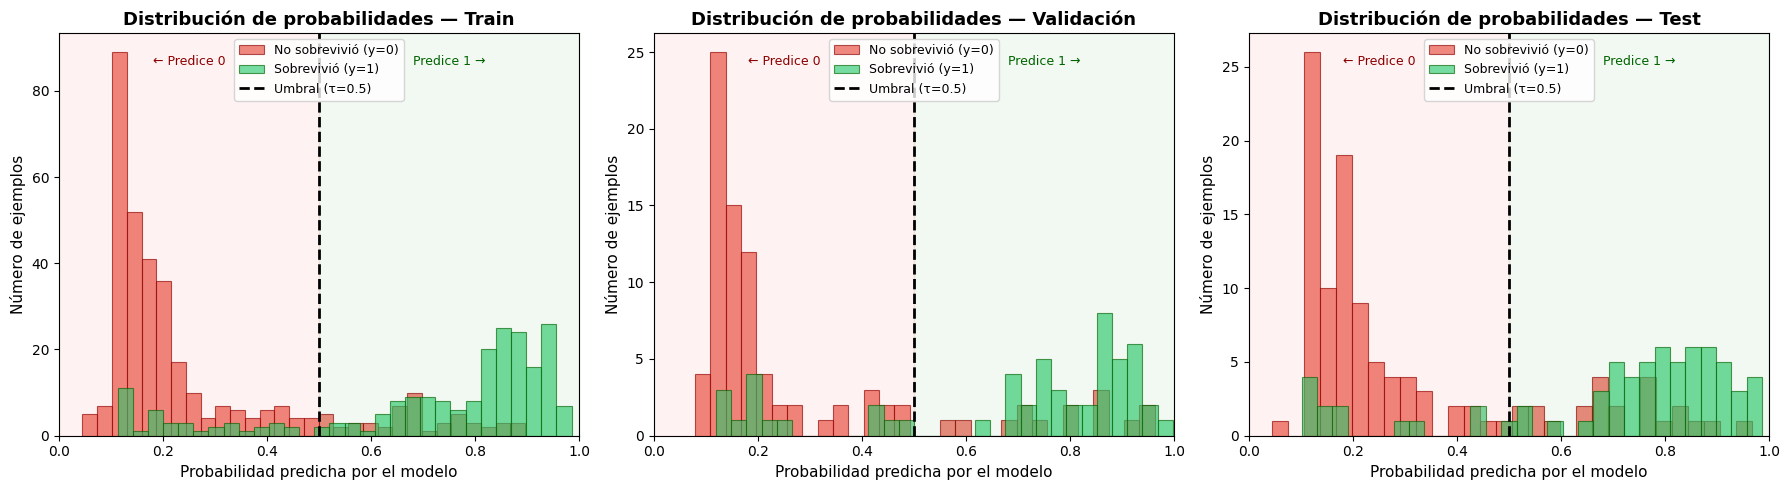

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Sacamos las probabilidades que el modelo asigna a cada ejemplo (antes de aplicar el umbral 0.5)
proba_train = model.predict_proba(X_train)
proba_val   = model.predict_proba(X_val)
proba_test  = model.predict_proba(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, proba, y_true, title in zip(
    axes,
    [proba_train, proba_val, proba_test],
    [y_train_arr, y_val_arr, y_test_arr],
    ['Train', 'Validación', 'Test']
):
    # Separamos las probabilidades según la clase real para ver si el modelo las distingue
    mask_0 = y_true == 0  # Los que NO sobrevivieron
    mask_1 = y_true == 1  # Los que SÍ sobrevivieron

    # Dibujamos un histograma para cada clase con colores bien diferenciados
    ax.hist(proba[mask_0], bins=30, alpha=0.65, color='#e74c3c', edgecolor='darkred',
            linewidth=0.8, label='No sobrevivió (y=0)')
    ax.hist(proba[mask_1], bins=30, alpha=0.65, color='#2ecc71', edgecolor='darkgreen',
            linewidth=0.8, label='Sobrevivió (y=1)')

    # Línea del umbral de decisión: a la izquierda se predice 0, a la derecha 1
    ax.axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Umbral (τ=0.5)')

    # Sombreamos las zonas de decisión para que quede más claro
    ax.axvspan(0, 0.5, alpha=0.05, color='red')    # Zona donde se predice 0
    ax.axvspan(0.5, 1, alpha=0.05, color='green')   # Zona donde se predice 1

    ax.set_xlabel('Probabilidad predicha por el modelo', fontsize=11)
    ax.set_ylabel('Número de ejemplos', fontsize=11)
    ax.set_title(f'Distribución de probabilidades — {title}', fontsize=13, fontweight='bold')
    ax.legend(loc='upper center', fontsize=9)
    ax.set_xlim(0, 1)

    # Añadimos texto con las etiquetas de las zonas de predicción
    ax.text(0.25, ax.get_ylim()[1]*0.92, '← Predice 0', ha='center', fontsize=9, color='darkred')
    ax.text(0.75, ax.get_ylim()[1]*0.92, 'Predice 1 →', ha='center', fontsize=9, color='darkgreen')

plt.tight_layout()
plt.show()